# ML Lab Assignment 3 

## Part A - Data Loading and Preprocessing with Scikit-learn

### Task 1 - Load and Understand the Dataset

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("D:\\DAUSem1\\ML\\Dataset\\hotel_bookings.csv")

# Display first 5 rows
print("FIRST 5 ROWS:")
print(df.head())

# Check dataset shape
print("\nDATASET SHAPE:")
print(df.shape)

# Check dataset information
print("\nDATASET INFO:")
df.info()

# Statistical summary
print("\nSTATISTICAL SUMMARY:")
print(df.describe())

# Check data types
print("\nDATA TYPES:")
print(df.dtypes)

# TARGET VARIABLE
# Check class distribution of is_canceled
print("\nCLASS DISTRIBUTION:")
print(df["is_canceled"].value_counts())

# Check class distribution percentage
print("\nCLASS DISTRIBUTION (%):")
print(df["is_canceled"].value_counts(normalize=True) * 100)

# Create target variable
y = df["is_canceled"]

# Create feature dataset by removing target column
X = df.drop("is_canceled", axis=1)


# IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# Numerical columns
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical columns
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Display columns
print("\nNUMERICAL COLUMNS:")
print(numerical_columns)

print("\nCATEGORICAL COLUMNS:")
print(categorical_columns)

FIRST 5 ROWS:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Dep

### Task 2 - Missing Values, Leakage, and Outliers

MISSING VALUE SUMMARY:
          Missing Count  Missing Percentage
agent             10030           11.188827
country             205            0.228685
children              4            0.004462

COLUMNS WITH MORE THAN 90% MISSING VALUES:
[]

Dropped high-missingness columns because they contain more than 90% missing values.

LEAKAGE COLUMNS REMOVED:
[]


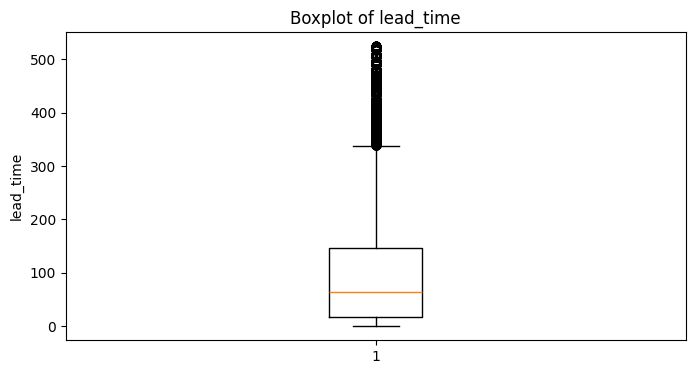

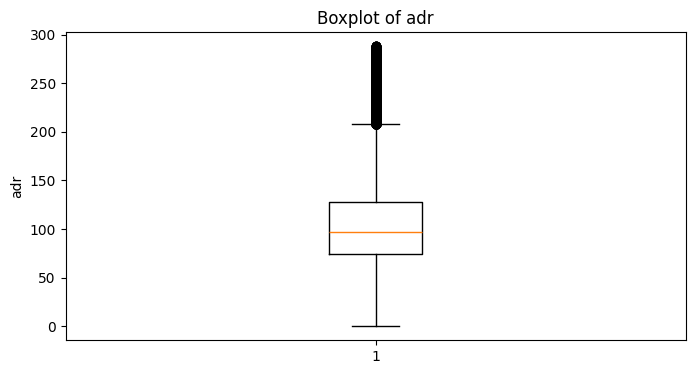

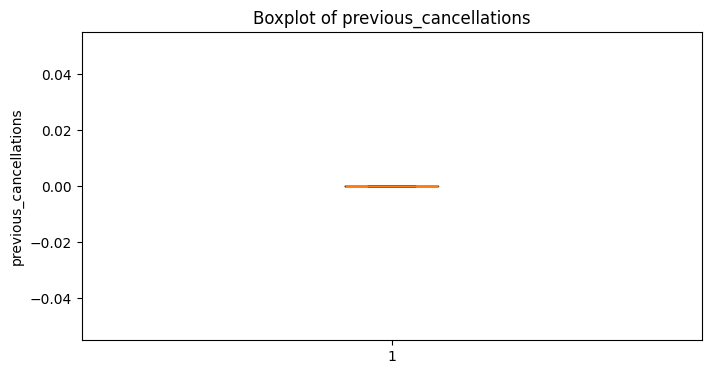

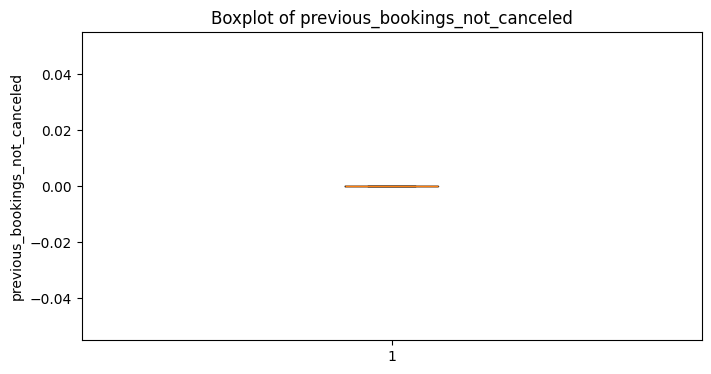

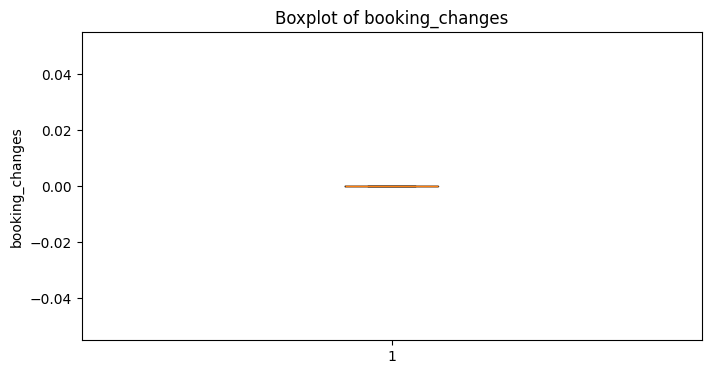

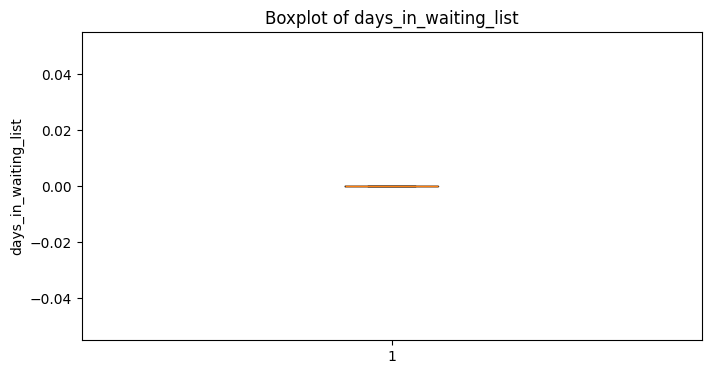


OUTLIER REMOVAL SUMMARY : 
Rows before outlier removal: 89643
Rows after outlier removal: 89643
Total rows removed: 0

FINAL SHAPE OF X: (89643, 28)
FINAL SHAPE OF y: (89643,)
Cleaned dataset saved successfully.
Cleaned dataset shape: (89643, 29)


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

#CHECK MISSING VALUES
missing_count = X.isnull().sum()

missing_percentage = (
    X.isnull().sum() / len(X) * 100
)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Show only columns with missing values
missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(by="Missing Percentage", ascending=False)

print("MISSING VALUE SUMMARY:")
print(missing_summary)



# DROP COLUMNS WITH VERY HIGH MISSINGNESS
# Columns with more than 90% missing values
high_missing_columns = missing_percentage[
    missing_percentage > 90
].index.tolist()

print("\nCOLUMNS WITH MORE THAN 90% MISSING VALUES:")
print(high_missing_columns)

# Drop these columns because too much data is missing
X = X.drop(columns=high_missing_columns)

print("\nDropped high-missingness columns because they contain more than 90% missing values.")


# REMOVE DATA LEAKAGE COLUMNS
leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

# Drop only if the columns exist
leakage_columns = [
    col for col in leakage_columns if col in X.columns
]

X = X.drop(columns=leakage_columns)

print("\nLEAKAGE COLUMNS REMOVED:")
print(leakage_columns)


# SELECT NUMERICAL FEATURES FOR OUTLIER CHECK
selected_numerical_columns = [
    "lead_time",
    "adr",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list"
]

# Keep only columns that exist
selected_numerical_columns = [
    col for col in selected_numerical_columns
    if col in X.columns
]

# CREATE BOXPLOTS
for column in selected_numerical_columns:
    
    plt.figure(figsize=(8, 4))
    
    plt.boxplot(X[column].dropna())
    
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    
    plt.show()

#  DETECT EXTREME OUTLIERS USING IQR
rows_before = len(X)

outlier_mask = pd.Series(False, index=X.index)

for column in selected_numerical_columns:
    
    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    # Identify extreme outliers
    column_outliers = (
        (X[column] < lower_bound) |
        (X[column] > upper_bound)
    )
    
    outlier_mask = outlier_mask | column_outliers


# Remove extreme outlier rows
X = X.loc[~outlier_mask]
y = y.loc[X.index]

rows_after = len(X)

rows_removed = rows_before - rows_after


# REPORT RESULTS
print("\nOUTLIER REMOVAL SUMMARY : ")
print("Rows before outlier removal:", rows_before)
print("Rows after outlier removal:", rows_after)
print("Total rows removed:", rows_removed)

print("\nFINAL SHAPE OF X:", X.shape)
print("FINAL SHAPE OF y:", y.shape)

# SAVE CLEANED DATASET

# Combine cleaned features and target
cleaned_df = X.copy()

cleaned_df["is_canceled"] = y

# Save as CSV
cleaned_df.to_csv(
    "D:\\DAUSem1\\ML\\Dataset\\hotel_bookings_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("Cleaned dataset shape:", cleaned_df.shape)

### Task 3 - Create Two Preprocessing Pipelines

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder


# SPLIT THE DATA
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)



# IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

# PIPELINE A
# KNNImputer + StandardScaler

# Numerical preprocessing for Pipeline A
numerical_pipeline_A = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing
preprocessor_A = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline_A, numerical_columns),
        ("cat", categorical_pipeline, categorical_columns)
    ]
)


# PIPELINE B
# KNNImputer + MinMaxScaler

# Numerical preprocessing for Pipeline B
numerical_pipeline_B = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

# Combine numerical and categorical preprocessing
preprocessor_B = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline_B, numerical_columns),
        ("cat", categorical_pipeline, categorical_columns)
    ]
)


#  DISPLAY THE PIPELINES

print("\nPIPELINE A:")
print("Numerical: KNNImputer(n_neighbors=5) + StandardScaler")
print("Categorical: SimpleImputer(most_frequent) + OneHotEncoder")

print("\nPIPELINE B:")
print("Numerical: KNNImputer(n_neighbors=5) + MinMaxScaler")
print("Categorical: SimpleImputer(most_frequent) + OneHotEncoder")


# OPTIONAL: TEST THE PREPROCESSORS

# Fit only on training data and transform training data
X_train_A = preprocessor_A.fit_transform(X_train)

# Transform test data using the already fitted preprocessor
X_test_A = preprocessor_A.transform(X_test)

print("\nPipeline A completed:")
print("X_train_A shape:", X_train_A.shape)
print("X_test_A shape:", X_test_A.shape)


# Fit Pipeline B only on training data
X_train_B = preprocessor_B.fit_transform(X_train)

# Transform test data using the already fitted preprocessor
X_test_B = preprocessor_B.transform(X_test)

print("\nPipeline B completed:")
print("X_train_B shape:", X_train_B.shape)
print("X_test_B shape:", X_test_B.shape)

Training data shape: (71897, 28)
Testing data shape: (17975, 28)

Numerical Columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

PIPELINE A:
Numerical: KNNImputer(n_neighbors=5) + StandardScaler
Categorical: SimpleImputer(most_frequent) + OneHotEncoder

PIPELINE B:
Numerical: KNNImputer(n_neighbors=5) + MinMaxScaler
Categorical: SimpleImputer(most_frequent) + OneHotEncoder

Pipeline A completed:
X_train_A shape: (71897, 249)
X_test_A shape: (17975, 249)

Pipeline B comple

## Part B - Model Training and Performance Evaluation

### Task 4 - Train Two Classification Models

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# LOGISTIC REGRESSION + PIPELINE A

logistic_pipeline_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_pipeline_A.fit(X_train, y_train)

print("Logistic Regression + Pipeline A trained successfully.")

# 2. LOGISTIC REGRESSION + PIPELINE B

logistic_pipeline_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_pipeline_B.fit(X_train, y_train)

print("Logistic Regression + Pipeline B trained successfully.")


# DECISION TREE + PIPELINE A

decision_tree_pipeline_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("model", DecisionTreeClassifier(random_state=42))
])

decision_tree_pipeline_A.fit(X_train, y_train)

print("Decision Tree + Pipeline A trained successfully.")

# 4. DECISION TREE + PIPELINE B

decision_tree_pipeline_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("model", DecisionTreeClassifier(random_state=42))
])

decision_tree_pipeline_B.fit(X_train, y_train)

print("Decision Tree + Pipeline B trained successfully.")

Logistic Regression + Pipeline A trained successfully.
Logistic Regression + Pipeline B trained successfully.
Decision Tree + Pipeline A trained successfully.
Decision Tree + Pipeline B trained successfully.


### Task 5 - Evaluate and Compare the Four Results

FINAL MODEL COMPARISON:


,Model + Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
0,Decision Tree + Pipeline B,0.9956,0.8468,0.7920,0.8021,0.7970,0.1489
1,Decision Tree + Pipeline A,0.9956,0.8461,0.7909,0.8017,0.7962,0.1495
2,Logistic Regression + Pipeline A,0.7968,0.7935,0.7737,0.6351,0.6976,0.0033
3,Logistic Regression + Pipeline B,0.7970,0.7934,0.7752,0.6327,0.6967,0.0035



BEST LOGISTIC REGRESSION:
Logistic Regression + Pipeline A

BEST DECISION TREE:
Decision Tree + Pipeline B


<Figure size 600x500 with 0 Axes>

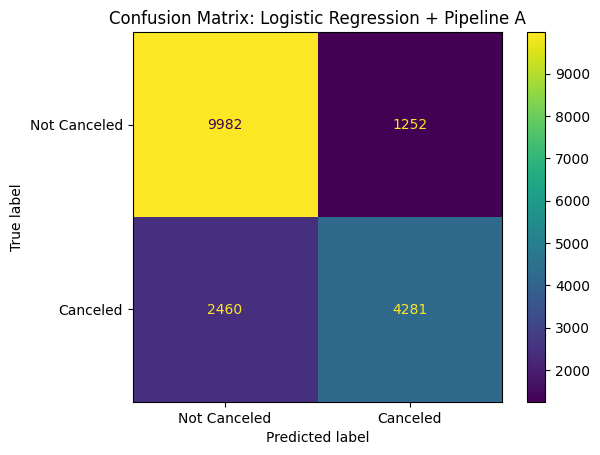

<Figure size 600x500 with 0 Axes>

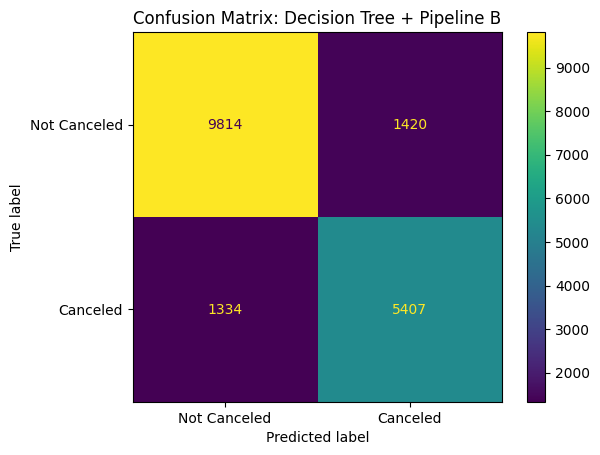


OVERFITTING ANALYSIS:
--------------------------------------------------

Decision Tree + Pipeline B
Training Accuracy: 0.9956
Testing Accuracy:  0.8468
Difference:        0.1489
Comment: Possible overfitting because the training accuracy is noticeably higher than the testing accuracy.

Decision Tree + Pipeline A
Training Accuracy: 0.9956
Testing Accuracy:  0.8461
Difference:        0.1495
Comment: Possible overfitting because the training accuracy is noticeably higher than the testing accuracy.

Logistic Regression + Pipeline A
Training Accuracy: 0.7968
Testing Accuracy:  0.7935
Difference:        0.0033
Comment: No strong sign of overfitting because training and testing accuracy are relatively close.

Logistic Regression + Pipeline B
Training Accuracy: 0.7970
Testing Accuracy:  0.7934
Difference:        0.0035
Comment: No strong sign of overfitting because training and testing accuracy are relatively close.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# STORE ALL FOUR EXPERIMENTS

experiments = {
    "Logistic Regression + Pipeline A": logistic_pipeline_A,
    "Logistic Regression + Pipeline B": logistic_pipeline_B,
    "Decision Tree + Pipeline A": decision_tree_pipeline_A,
    "Decision Tree + Pipeline B": decision_tree_pipeline_B
}


# EVALUATE EACH MODEL

results = []

for name, model in experiments.items():

    # Predictions on training data
    y_train_pred = model.predict(X_train)

    # Predictions on testing data
    y_test_pred = model.predict(X_test)

    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    precision = precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    # Store results
    results.append({
        "Model + Pipeline": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Train-Test Difference": train_accuracy - test_accuracy
    })

# CREATE FINAL COMPARISON TABLE

comparison_table = pd.DataFrame(results)

# Sort by F1-score from highest to lowest
comparison_table = comparison_table.sort_values(
    by="F1-Score",
    ascending=False
)

# Reset index
comparison_table = comparison_table.reset_index(drop=True)

# Display rounded results
print("FINAL MODEL COMPARISON:")
display(comparison_table.round(4))

# FIND BEST LOGISTIC REGRESSION RESULT

best_logistic = comparison_table[
    comparison_table["Model + Pipeline"].str.contains(
        "Logistic Regression"
    )
].sort_values(
    by="F1-Score",
    ascending=False
).iloc[0]

best_logistic_name = best_logistic["Model + Pipeline"]

print("\nBEST LOGISTIC REGRESSION:")
print(best_logistic_name)

# FIND BEST DECISION TREE RESULT

best_tree = comparison_table[
    comparison_table["Model + Pipeline"].str.contains(
        "Decision Tree"
    )
].sort_values(
    by="F1-Score",
    ascending=False
).iloc[0]

best_tree_name = best_tree["Model + Pipeline"]

print("\nBEST DECISION TREE:")
print(best_tree_name)

# GET THE CORRESPONDING MODELS

best_logistic_model = experiments[best_logistic_name]
best_tree_model = experiments[best_tree_name]

# CONFUSION MATRIX - BEST LOGISTIC MODEL

y_pred_best_logistic = best_logistic_model.predict(X_test)

cm_logistic = confusion_matrix(
    y_test,
    y_pred_best_logistic
)

display_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

plt.figure(figsize=(6, 5))

display_logistic.plot()

plt.title(f"Confusion Matrix: {best_logistic_name}")

plt.show()

# CONFUSION MATRIX - BEST DECISION TREE

y_pred_best_tree = best_tree_model.predict(X_test)

cm_tree = confusion_matrix(
    y_test,
    y_pred_best_tree
)

display_tree = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)

plt.figure(figsize=(6, 5))

display_tree.plot()

plt.title(f"Confusion Matrix: {best_tree_name}")

plt.show()

# CHECK FOR POSSIBLE OVERFITTING

print("\nOVERFITTING ANALYSIS:")
print("-" * 50)

for index, row in comparison_table.iterrows():

    difference = row["Train-Test Difference"]

    print(f"\n{row['Model + Pipeline']}")
    print(f"Training Accuracy: {row['Training Accuracy']:.4f}")
    print(f"Testing Accuracy:  {row['Testing Accuracy']:.4f}")
    print(f"Difference:        {difference:.4f}")

    if difference > 0.05:
        print("Comment: Possible overfitting because the training accuracy is noticeably higher than the testing accuracy.")

    else:
        print("Comment: No strong sign of overfitting because training and testing accuracy are relatively close.")

### Task 6 - Final Observations

In [6]:
# Best overall model based on F1-score
best_overall = comparison_table.iloc[0]

print("BEST OVERALL COMBINATION:")
print(best_overall["Model + Pipeline"])

print("\nPerformance:")
print(f"Testing Accuracy: {best_overall['Testing Accuracy']:.4f}")
print(f"Precision: {best_overall['Precision']:.4f}")
print(f"Recall: {best_overall['Recall']:.4f}")
print(f"F1-Score: {best_overall['F1-Score']:.4f}")

# Compare StandardScaler vs MinMaxScaler for Logistic Regression

logistic_results = comparison_table[
    comparison_table["Model + Pipeline"].str.contains(
        "Logistic Regression"
    )
]

print("\nLOGISTIC REGRESSION COMPARISON:")
print(
    logistic_results[
        ["Model + Pipeline", "Testing Accuracy", "Precision", "Recall", "F1-Score"]
    ].round(4)
)

# Compare StandardScaler vs MinMaxScaler for Decision Tree

tree_results = comparison_table[
    comparison_table["Model + Pipeline"].str.contains(
        "Decision Tree"
    )
]

print("\nDECISION TREE COMPARISON:")
print(
    tree_results[
        ["Model + Pipeline", "Testing Accuracy", "Precision", "Recall", "F1-Score"]
    ].round(4)
)

BEST OVERALL COMBINATION:
Decision Tree + Pipeline B

Performance:
Testing Accuracy: 0.8468
Precision: 0.7920
Recall: 0.8021
F1-Score: 0.7970

LOGISTIC REGRESSION COMPARISON:
                   Model + Pipeline  Testing Accuracy  Precision  Recall  \
2  Logistic Regression + Pipeline A            0.7935     0.7737  0.6351   
3  Logistic Regression + Pipeline B            0.7934     0.7752  0.6327   

   F1-Score  
2    0.6976  
3    0.6967  

DECISION TREE COMPARISON:
             Model + Pipeline  Testing Accuracy  Precision  Recall  F1-Score
0  Decision Tree + Pipeline B            0.8468     0.7920  0.8021    0.7970
1  Decision Tree + Pipeline A            0.8461     0.7909  0.8017    0.7962


## Final Observations

### 1. Best overall model: The [model + pipeline name] produced the best overall performance with a testing accuracy of [value] and an F1-score of [value]. Therefore, this combination was selected as the best-performing model.

### 2. Effect of scaling on Logistic Regression: Logistic Regression using [StandardScaler / MinMaxScaler] performed better based on [F1-score/testing accuracy]. This shows that the choice of scaling method [had a noticeable effect / had only a small effect] on Logistic Regression.

### 3. Effect of scaling on Decision Tree: The Decision Tree results using Pipeline A and Pipeline B were [very similar / noticeably different]. Since Decision Trees make splits based on feature thresholds, they are generally less sensitive to feature scaling than Logistic Regression.

### 4. Overfitting observation: The [model name] showed the largest difference between training and testing accuracy, suggesting possible overfitting. The model with a smaller train-test difference showed better generalization to unseen data.

### 5. Confusion matrix observation: The confusion matrices show how well the best Logistic Regression and Decision Tree models distinguish between canceled and not canceled bookings. The better model generally has more correct predictions on the main diagonal and fewer false positives and false negatives.